# 📊 AprovaEdu Analytics — Insights Complementares (Grupo A)

Análises **adicionais** sobre as tabelas que vieram **completas** no dataset —
`aprovacoes` e `ofertas_curso`. Diferente do `02_analise.ipynb` (que depende de
cruzamentos entre tabelas amostrais), **aqui não há ressalva amostral**: cada
número repousa em dado íntegro.

- **Aprovações** (354 registros, 306 alunos, tabela completa) — para onde e como os
  alunos são aprovados.
- **Ofertas de curso** (220 registros, completa) — como o cursinho se organiza e precifica.

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
FINAL = ROOT / "data" / "final"

aprovacoes = pd.read_parquet(FINAL / "aprovacoes.parquet")
ofertas = pd.read_parquet(FINAL / "ofertas_curso.parquet")

PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
BLUE, AQUA, YELLOW = PAL[0], PAL[1], PAL[2]
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 11,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
print("Aprovações:", aprovacoes.shape, "| Ofertas:", ofertas.shape)

Aprovações: (339, 11) | Ofertas: (220, 12)


## 2. Aprovações — para onde e como os alunos entram

### 2.1 Universidades que mais aprovam

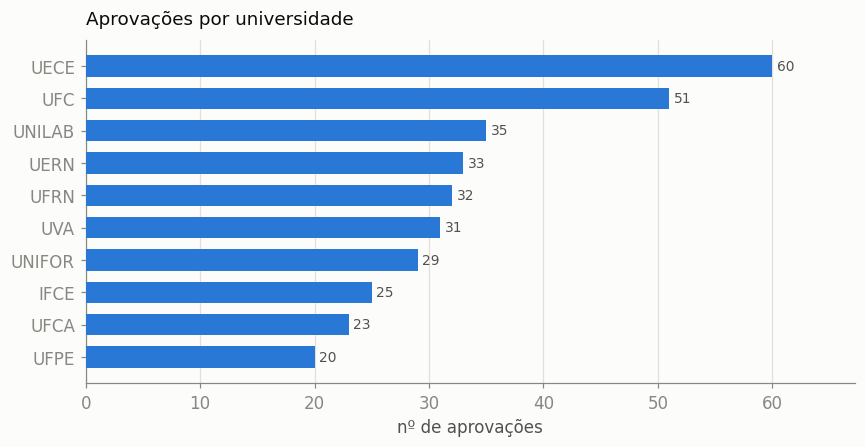

In [2]:
uni = aprovacoes["universidade"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.2))
b = ax.barh(uni.index, uni.values, color=BLUE, height=0.66, zorder=3)
ax.bar_label(b, padding=3, color=INK2, fontsize=9)
ax.set_title("Aprovações por universidade", color=INK, fontsize=12, loc="left", pad=10)
ax.set_xlabel("nº de aprovações"); ax.grid(axis="y", visible=False); ax.margins(x=0.12)
fig.tight_layout(); plt.show()

UECE e UFC concentram o maior volume de aprovações — as instituições públicas locais são o principal destino dos alunos.

### 2.2 Tipo de vaga: cotas x ampla concorrência

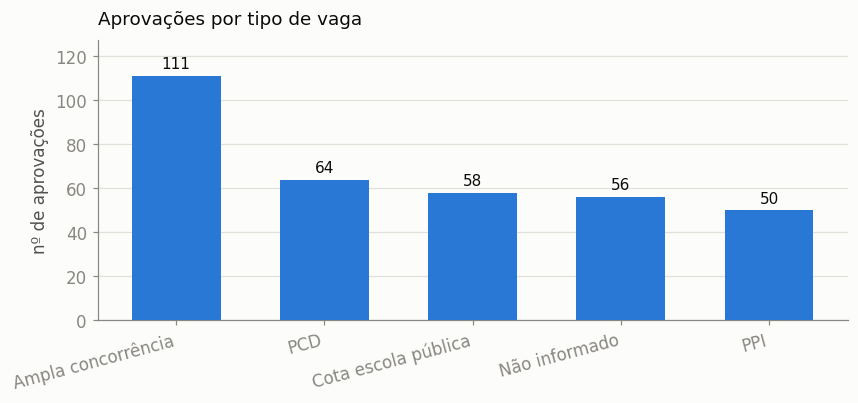

Cotas somadas (PPI+PCD+cota escola pública) = 172  vs  Ampla concorrência = 111


In [3]:
vaga = aprovacoes["modalidade_vaga"].value_counts()
cotas = vaga[[i for i in vaga.index if i in ("PPI", "PCD", "Cota escola pública")]].sum()
ampla = int(vaga.get("Ampla concorrência", 0))
fig, ax = plt.subplots(figsize=(8, 3.8))
b = ax.bar(vaga.index, vaga.values, color=BLUE, width=0.6, zorder=3)
ax.bar_label(b, padding=3, color=INK, fontsize=10)
ax.set_title("Aprovações por tipo de vaga", color=INK, fontsize=12, loc="left", pad=10)
ax.set_ylabel("nº de aprovações"); ax.grid(axis="x", visible=False); ax.margins(y=0.15)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
fig.tight_layout(); plt.show()
print(f"Cotas somadas (PPI+PCD+cota escola pública) = {cotas}  vs  Ampla concorrência = {ampla}")

Somadas, as **vagas por cota (PPI, PCD, escola pública) superam a ampla concorrência** — sinal de que a política de cotas é a principal via de aprovação dos alunos do cursinho.

### 2.3 Via de ingresso

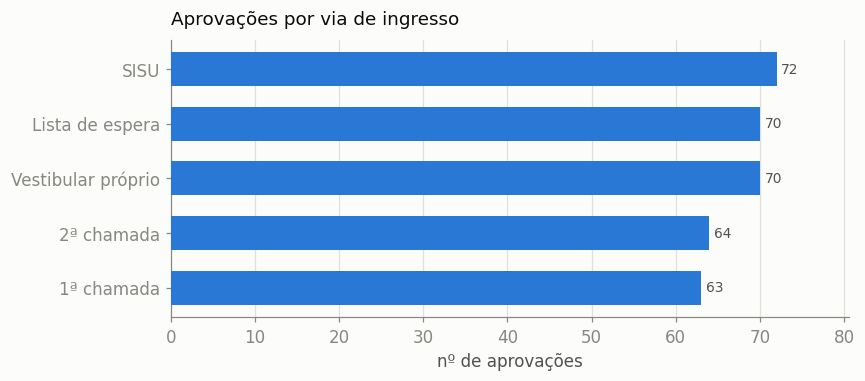

In [4]:
cham = aprovacoes["chamada"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, 3.6))
b = ax.barh(cham.index, cham.values, color=BLUE, height=0.62, zorder=3)
ax.bar_label(b, padding=3, color=INK2, fontsize=9)
ax.set_title("Aprovações por via de ingresso", color=INK, fontsize=12, loc="left", pad=10)
ax.set_xlabel("nº de aprovações"); ax.grid(axis="y", visible=False); ax.margins(x=0.12)
fig.tight_layout(); plt.show()

As vias estão bem distribuídas (SISU, vestibular próprio, listas e chamadas) — não há dependência de um único mecanismo de ingresso.

### 2.4 Seletividade: nota final por tipo de vaga

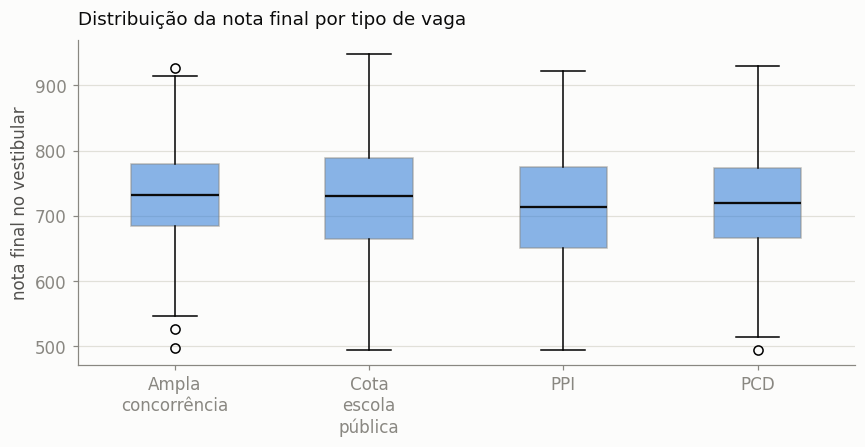

modalidade_vaga
Ampla concorrência     731.7
Cota escola pública    730.0
Não informado          726.2
PCD                    719.7
PPI                    714.0
Name: nota_final_vestibular, dtype: float64

In [5]:
grupos = ["Ampla concorrência", "Cota escola pública", "PPI", "PCD"]
dados = [aprovacoes.loc[aprovacoes["modalidade_vaga"] == g, "nota_final_vestibular"].dropna() for g in grupos]
fig, ax = plt.subplots(figsize=(8, 4.2))
bp = ax.boxplot(dados, vert=True, patch_artist=True, labels=[g.replace(" ", "\n") for g in grupos],
                medianprops=dict(color=INK, linewidth=1.5))
for patch in bp["boxes"]:
    patch.set_facecolor(BLUE); patch.set_alpha(0.55); patch.set_edgecolor(MUTED)
ax.set_title("Distribuição da nota final por tipo de vaga", color=INK, fontsize=12, loc="left", pad=10)
ax.set_ylabel("nota final no vestibular"); ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()
aprovacoes.groupby("modalidade_vaga")["nota_final_vestibular"].median().round(1)

O boxplot permite comparar as **faixas de nota de corte** por tipo de vaga — diferenças entre cotas e ampla concorrência aparecem na distribuição, não só na média.

## 3. Ofertas de curso — organização e preço

### 3.1 Preço médio por matéria

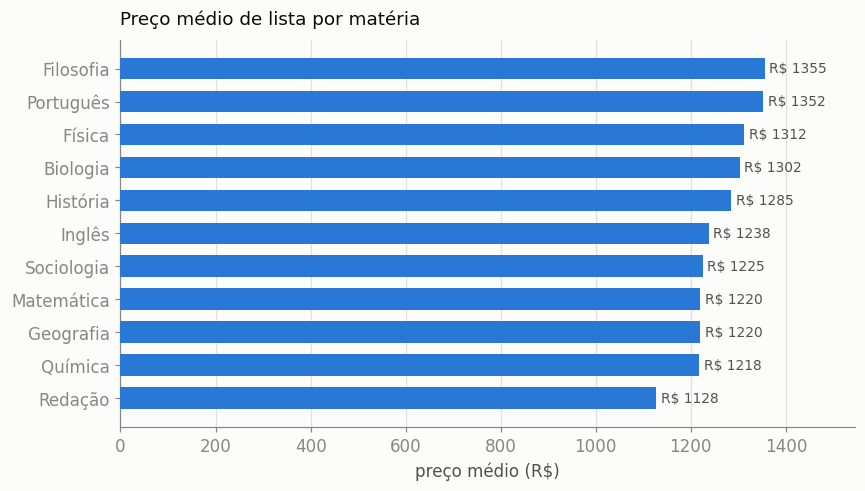

In [6]:
preco = ofertas.groupby("materia")["preco_lista"].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.6))
b = ax.barh(preco.index, preco.values, color=BLUE, height=0.66, zorder=3)
ax.bar_label(b, fmt="R$ %.0f", padding=3, color=INK2, fontsize=9)
ax.set_title("Preço médio de lista por matéria", color=INK, fontsize=12, loc="left", pad=10)
ax.set_xlabel("preço médio (R$)"); ax.grid(axis="y", visible=False); ax.margins(x=0.14)
fig.tight_layout(); plt.show()

Os preços médios são relativamente próximos entre matérias — a precificação não parece seguir a matéria como fator principal.

### 3.2 Composição de modalidade por ano

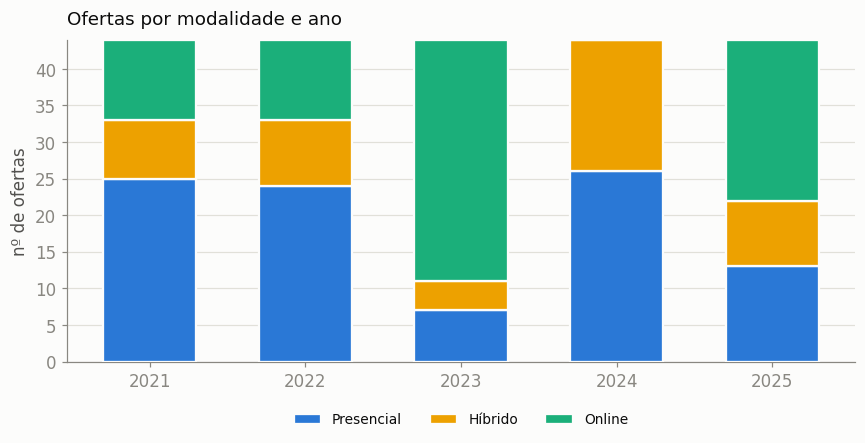

In [7]:
mix = pd.crosstab(ofertas["ano"], ofertas["modalidade"])
mix = mix[[c for c in ["Presencial", "Híbrido", "Online"] if c in mix.columns]]
cores = {"Presencial": BLUE, "Híbrido": YELLOW, "Online": AQUA}
fig, ax = plt.subplots(figsize=(8, 4.2))
base = np.zeros(len(mix))
for col in mix.columns:
    ax.bar(mix.index.astype(int), mix[col], bottom=base, label=col, color=cores[col],
           width=0.6, zorder=3, edgecolor=SURF, linewidth=1.5)
    base += mix[col].values
ax.set_title("Ofertas por modalidade e ano", color=INK, fontsize=12, loc="left", pad=10)
ax.set_ylabel("nº de ofertas"); ax.set_xticks(mix.index.astype(int))
ax.grid(axis="x", visible=False); ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper center",
        bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(); plt.show()

A composição **varia bastante de ano para ano, sem tendência linear** (2023 teve pico de online; 2024 concentrou-se em presencial/híbrido). Não há, nos dados, um movimento consistente de digitalização — a oferta parece responder a decisões pontuais de cada ano.

## 4. Síntese dos insights (dados completos, sem ressalva)

1. **Público majoritariamente cotista** — as vagas por cota superam a ampla concorrência;
   a coordenação pode reforçar orientação sobre políticas de cota.
2. **Destino concentrado em públicas locais** (UECE, UFC) — útil para direcionar
   preparação a esses vestibulares/SISU.
3. **Ingresso diversificado** — nenhuma via domina; vale acompanhar SISU e vestibulares
   próprios em paralelo.
4. **Preço homogêneo entre matérias** — a matéria não é o eixo de precificação.
5. **Oferta de modalidade instável entre anos** — sem tendência de digitalização;
   padronizar essa decisão pode dar previsibilidade operacional.

> Estas análises usam apenas tabelas **completas** (`aprovacoes`, `ofertas_curso`), então
> valem como conclusões — diferente do `02_analise.ipynb`, limitado pelos cruzamentos amostrais.